In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

## LOAD DATASETS IN
*NOTE: Institution file isn't pure UTF-8 - use pd.read_csv(..., encoding="cp1252") to avoid a UnicodeDecodeError.*

In [15]:
field_of_study = pd.read_csv("Most-Recent-Cohorts-Field-of-Study_features_filtered.csv")
institution = pd.read_csv("Most-Recent-Cohorts-Institution_features.csv", encoding = "cp1252")

print(field_of_study.shape)
print(institution.shape)

(28662, 18)
(6273, 55)


## Missing Values Analysis
*NOTE: For all 'missing' values, this includes blanks, NA, and PS (privacy-suppressed) information*

In [23]:
missing_codes = ["PS", "NA", ""]

studyfield_missing = (field_of_study.isnull() | field_of_study.isin(missing_codes)).sum()
institution_missing = (institution.isnull() | institution.isin(missing_codes)).sum()

In [24]:
print((studyfield_missing / len(field_of_study) * 100).round(1).sort_values(ascending = False))
print((institution_missing / len(institution) * 100).round(1).sort_values(ascending = False))

DEBT_ALL_STGP_EVAL_N      85.3
DEBT_ALL_STGP_EVAL_MDN    85.2
EARN_MDN_HI_1YR           82.4
EARN_MDN_5YR              81.8
EARN_COUNT_WNE_5YR        81.8
EARN_MDN_1YR              81.0
EARN_COUNT_WNE_1YR        81.0
IPEDSCOUNT1               15.0
IPEDSCOUNT2               13.5
UNITID                     3.2
CREDDESC                   0.0
OPEID6                     0.0
CREDLEV                    0.0
CIPDESC                    0.0
CIPCODE                    0.0
MAIN                       0.0
CONTROL                    0.0
INSTNM                     0.0
dtype: float64
RET_PT4           78.2
RET_PTL4          74.9
ADM_RATE          69.6
RET_FT4           67.2
C150_4            63.9
UGNONDS           55.7
RET_FTL4          55.3
C150_L4           54.6
COSTT4_A          49.0
PFTFAC            44.9
TUITIONFEE_IN     42.4
TUITIONFEE_OUT    42.4
AVGFACSAL         39.7
OPENADMP          14.6
PCTPELL           13.2
PCTFLOAN          13.2
STUFACR           12.8
UGDS_WHITE        12.7
UGDS_MEN     

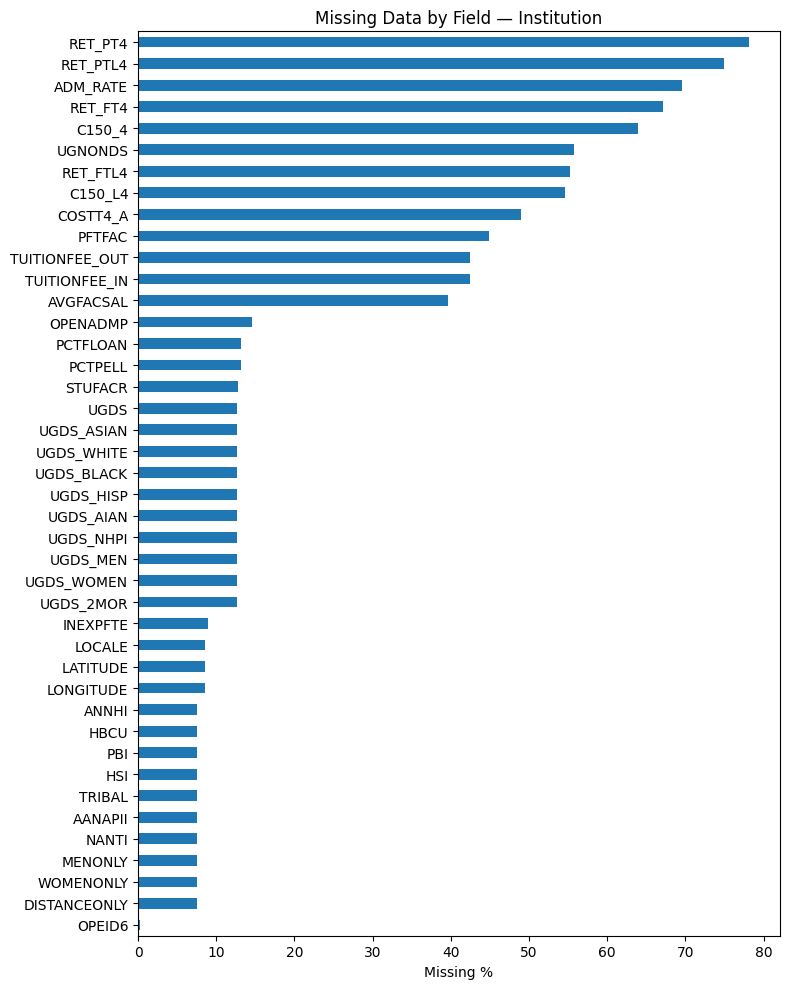

In [25]:
institution_pct = (institution_missing / len(institution) * 100).round(1)

institution_pct[institution_pct > 0].sort_values().plot(kind = "barh", figsize = (8, 10))
plt.xlabel("Missing %")
plt.title("Missing Data by Field — Institution")
plt.tight_layout()
plt.show()

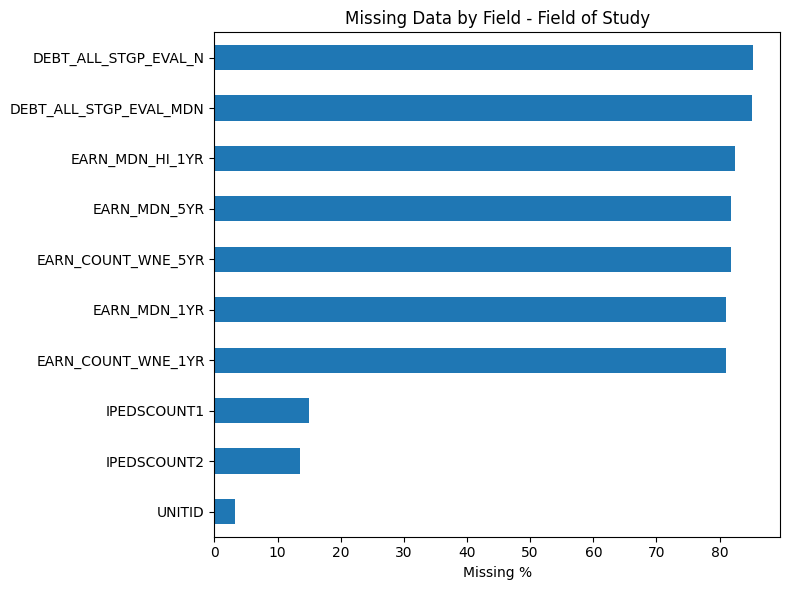

In [26]:
studyfield_pct = (studyfield_missing / len(field_of_study) * 100).round(1)

studyfield_pct[studyfield_pct > 0].sort_values().plot(kind = "barh", figsize = (8, 6))
plt.xlabel("Missing %")
plt.title("Missing Data by Field - Field of Study")
plt.tight_layout()
plt.show()